# AI-Based Sentiment and Trend Analysis System

**GitHub Repository:**  
https://github.com/arslan01000/AI-Based-Sentiment-and-Trend-Analysis-System

This notebook includes data preprocessing, exploratory data analysis, TF-IDF feature extraction, model training, model comparison, and final evaluation for sentiment analysis of Twitter and Reddit discussions.

In [3]:
import re
import string

# Create a copy of the combined dataset
df_clean = df.copy()

# Remove missing values from text and category
df_clean = df_clean.dropna(subset=["text", "category"])

# Remove duplicate rows
df_clean = df_clean.drop_duplicates(subset=["text"])

# Convert category to integer
df_clean["category"] = df_clean["category"].astype(int)

# Function to clean text
def clean_text(text):
    text = str(text).lower()                         # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+", "", text)                 # remove mentions
    text = re.sub(r"#", "", text)                    # remove hashtag symbol only
    text = re.sub(r"[^a-zA-Z\s]", "", text)          # remove punctuation/numbers/special chars
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces
    return text

# Apply cleaning
df_clean["cleaned_text"] = df_clean["text"].apply(clean_text)

# Remove empty cleaned text rows
df_clean = df_clean[df_clean["cleaned_text"] != ""]

# Show final cleaned dataset information
print("Original combined dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

print("\nLabel distribution after cleaning:")
print(df_clean["category"].value_counts())

print("\nBefore and after cleaning examples:")
display(df_clean[["text", "cleaned_text", "category", "source"]].head(10))

Original combined dataset shape: (45208, 3)
Cleaned dataset shape: (44936, 4)

Missing values after cleaning:
text            0
category        0
source          0
cleaned_text    0
dtype: int64

Label distribution after cleaning:
category
 1    19363
 0    14985
-1    10588
Name: count, dtype: int64

Before and after cleaning examples:


,text,cleaned_text,category,source
0,when modi promised “minimum government maximum...,when modi promised minimum government maximum ...,-1,Twitter
1,talk all the nonsense and continue all the dra...,talk all the nonsense and continue all the dra...,0,Twitter
2,what did just say vote for modi welcome bjp t...,what did just say vote for modi welcome bjp to...,1,Twitter
3,asking his supporters prefix chowkidar their n...,asking his supporters prefix chowkidar their n...,1,Twitter
4,answer who among these the most powerful world...,answer who among these the most powerful world...,1,Twitter
5,kiya tho refresh maarkefir comment karo,kiya tho refresh maarkefir comment karo,0,Twitter
6,surat women perform yagna seeks divine grace f...,surat women perform yagna seeks divine grace f...,0,Twitter
7,this comes from cabinet which has scholars lik...,this comes from cabinet which has scholars lik...,0,Twitter
8,with upcoming election india saga going import...,with upcoming election india saga going import...,1,Twitter
9,gandhi was gay does modi,gandhi was gay does modi,1,Twitter


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [4]:
import nltk
from nltk.corpus import stopwords

# Download stopwords
nltk.download("stopwords")

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Function to remove stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# Apply stopword removal
df_clean["final_text"] = df_clean["cleaned_text"].apply(remove_stopwords)

# Remove rows that became empty after stopword removal
df_clean = df_clean[df_clean["final_text"] != ""]

# Show final dataset info
print("Final cleaned dataset shape:", df_clean.shape)

print("\nLabel distribution:")
print(df_clean["category"].value_counts())

print("\nFinal text examples:")
display(df_clean[["text", "cleaned_text", "final_text", "category", "source"]].head(10))

# Save cleaned dataset
df_clean.to_csv("cleaned_social_media_sentiment_dataset.csv", index=False)

print("\nCleaned dataset saved as: cleaned_social_media_sentiment_dataset.csv")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Final cleaned dataset shape: (44889, 5)

Label distribution:
category
 1    19362
 0    14941
-1    10586
Name: count, dtype: int64

Final text examples:


,text,cleaned_text,final_text,category,source
0,when modi promised “minimum government maximum...,when modi promised minimum government maximum ...,modi promised minimum government maximum gover...,-1,Twitter
1,talk all the nonsense and continue all the dra...,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi,0,Twitter
2,what did just say vote for modi welcome bjp t...,what did just say vote for modi welcome bjp to...,say vote modi welcome bjp told rahul main camp...,1,Twitter
3,asking his supporters prefix chowkidar their n...,asking his supporters prefix chowkidar their n...,asking supporters prefix chowkidar names modi ...,1,Twitter
4,answer who among these the most powerful world...,answer who among these the most powerful world...,answer among powerful world leader today trump...,1,Twitter
5,kiya tho refresh maarkefir comment karo,kiya tho refresh maarkefir comment karo,kiya tho refresh maarkefir comment karo,0,Twitter
6,surat women perform yagna seeks divine grace f...,surat women perform yagna seeks divine grace f...,surat women perform yagna seeks divine grace n...,0,Twitter
7,this comes from cabinet which has scholars lik...,this comes from cabinet which has scholars lik...,comes cabinet scholars like modi smriti hema t...,0,Twitter
8,with upcoming election india saga going import...,with upcoming election india saga going import...,upcoming election india saga going important p...,1,Twitter
9,gandhi was gay does modi,gandhi was gay does modi,gandhi gay modi,1,Twitter



Cleaned dataset saved as: cleaned_social_media_sentiment_dataset.csv


# Part 4 — Exploratory Data Analysis / Visualizations

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load cleaned dataset
df = pd.read_csv("cleaned_social_media_sentiment_dataset.csv")

# Show basic information
print("Dataset shape:", df.shape)
display(df.head())

# Check columns
print("Columns:")
print(df.columns)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (44889, 5)


,text,category,source,cleaned_text,final_text
0,when modi promised “minimum government maximum...,-1,Twitter,when modi promised minimum government maximum ...,modi promised minimum government maximum gover...
1,talk all the nonsense and continue all the dra...,0,Twitter,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi
2,what did just say vote for modi welcome bjp t...,1,Twitter,what did just say vote for modi welcome bjp to...,say vote modi welcome bjp told rahul main camp...
3,asking his supporters prefix chowkidar their n...,1,Twitter,asking his supporters prefix chowkidar their n...,asking supporters prefix chowkidar names modi ...
4,answer who among these the most powerful world...,1,Twitter,answer who among these the most powerful world...,answer among powerful world leader today trump...


Columns:
Index(['text', 'category', 'source', 'cleaned_text', 'final_text'], dtype='object')

Missing values:
text            0
category        0
source          0
cleaned_text    0
final_text      0
dtype: int64


## 2. Label Distribution Chart

This chart shows how many texts belong to each sentiment category: negative, neutral, and positive.

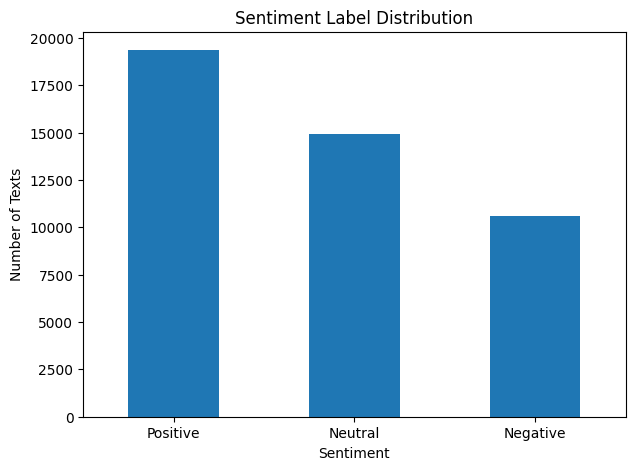

sentiment
Positive    19362
Neutral     14941
Negative    10586
Name: count, dtype: int64


In [6]:
# Map numeric labels to readable names
label_map = {
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
}

df["sentiment"] = df["category"].map(label_map)

# Count each sentiment
label_counts = df["sentiment"].value_counts()

# Plot label distribution
plt.figure(figsize=(7,5))
label_counts.plot(kind="bar")

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Texts")
plt.xticks(rotation=0)
plt.show()

# Show exact counts
print(label_counts)

The sentiment distribution shows that positive texts appear most frequently, followed by neutral and negative texts. This means the dataset is not perfectly balanced, but all three sentiment categories have enough examples for model training.

## 3. Source Distribution Chart

This chart shows how many records came from each platform: Twitter and Reddit.

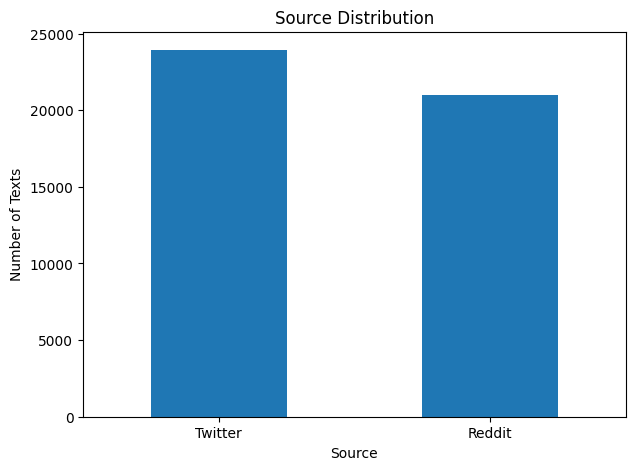

source
Twitter    23925
Reddit     20964
Name: count, dtype: int64


In [8]:
# Count source values
source_counts = df["source"].value_counts()

# Plot source distribution
plt.figure(figsize=(7,5))
source_counts.plot(kind="bar")

plt.title("Source Distribution")
plt.xlabel("Source")
plt.ylabel("Number of Texts")
plt.xticks(rotation=0)
plt.show()

# Show exact counts
print(source_counts)

The source distribution shows that the dataset contains texts from both Twitter and Reddit. Twitter has slightly more records than Reddit, but both sources are well represented, which gives the project a broader social media dataset.

## 4. Text Length Distribution

This chart shows how long the cleaned texts are based on word count.

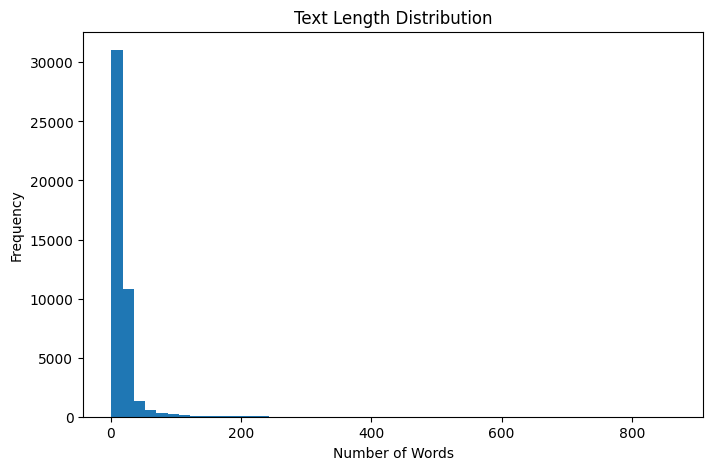

count    44889.000000
mean        17.540600
std         27.716643
min          1.000000
25%          6.000000
50%         12.000000
75%         21.000000
max        866.000000
Name: text_length, dtype: float64


In [9]:
# Create text length column based on number of words
df["text_length"] = df["final_text"].astype(str).apply(lambda x: len(x.split()))

# Plot text length distribution
plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=50)

plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Show basic statistics
print(df["text_length"].describe())

The text length distribution shows that most cleaned texts are short, with a median length of 12 words and an average length of about 18 words. This is expected for social media data because posts and comments are usually brief. A few longer texts create a long right tail in the distribution.

## 5. Average Text Length by Sentiment

This chart compares the average number of words for negative, neutral, and positive texts.

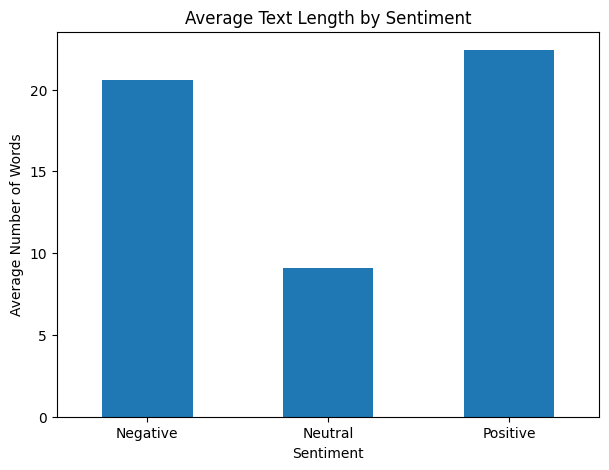

sentiment
Negative    20.592953
Neutral      9.065324
Positive    22.411838
Name: text_length, dtype: float64


In [10]:
# Calculate average text length by sentiment
avg_length = df.groupby("sentiment")["text_length"].mean()

# Plot average text length by sentiment
plt.figure(figsize=(7,5))
avg_length.plot(kind="bar")

plt.title("Average Text Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Number of Words")
plt.xticks(rotation=0)
plt.show()

# Show exact values
print(avg_length)

Positive texts have the highest average length at about 22 words, followed by negative texts at about 21 words. Neutral texts are much shorter, with an average length of about 9 words. This suggests that opinion-based posts may contain more detailed language than neutral posts.

## 6. Most Frequent Words

This chart shows the most common words in the cleaned social media text.

,word,count
0,modi,25953
1,india,6940
2,people,5888
3,bjp,5677
4,like,5083
5,one,3701
6,congress,3333
7,good,3190
8,even,2801
9,get,2798


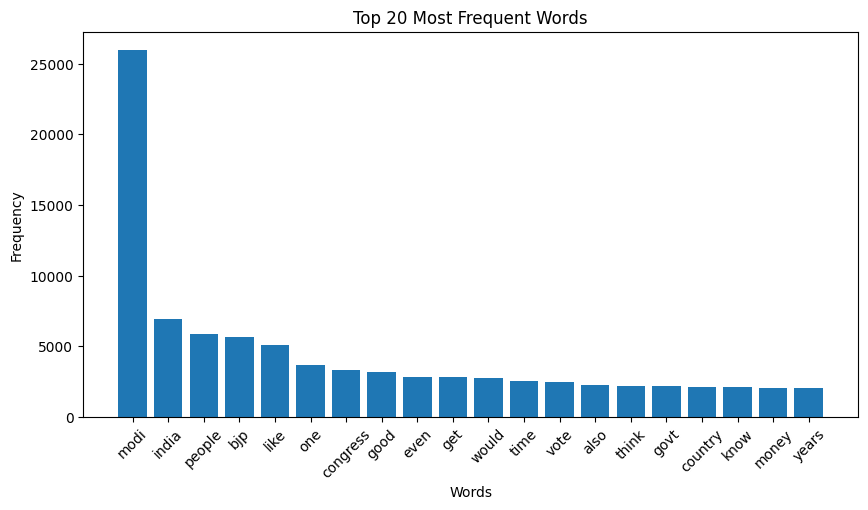

In [11]:
# Combine all cleaned text into one list of words
all_words = " ".join(df["final_text"].astype(str)).split()

# Count word frequencies
word_counts = Counter(all_words)

# Get top 20 most common words
common_words = word_counts.most_common(20)

# Convert to DataFrame
common_words_df = pd.DataFrame(common_words, columns=["word", "count"])

# Display table
display(common_words_df)

# Plot most frequent words
plt.figure(figsize=(10,5))
plt.bar(common_words_df["word"], common_words_df["count"])

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

The most frequent words show that the dataset contains many repeated political and social discussion terms. The word “modi” appears very frequently, which suggests that a large part of the dataset includes political discussion. This is useful to understand the dataset context before training the NLP model.

## 7. Word Cloud

This word cloud visually shows the most common words in the cleaned dataset.

In [12]:
!pip install wordcloud

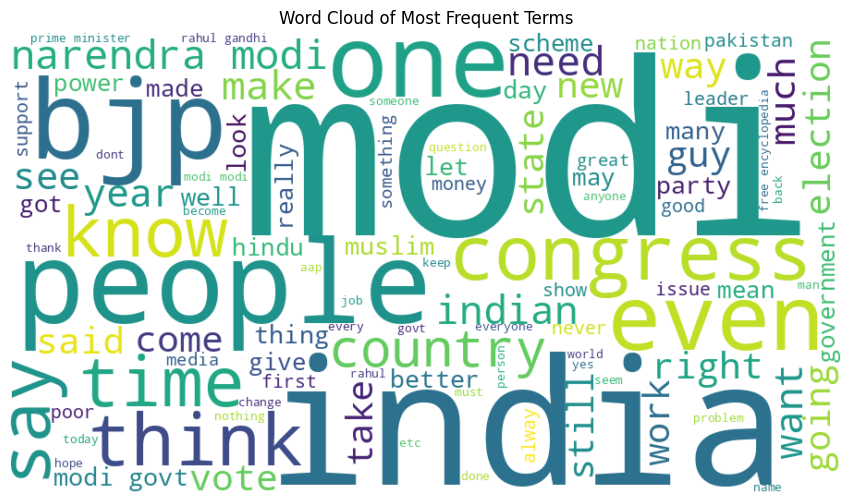

In [13]:
from wordcloud import WordCloud

# Combine text
text_data = " ".join(df["final_text"].astype(str))

# Generate word cloud
wordcloud = WordCloud(
    width=900,
    height=500,
    background_color="white",
    max_words=100
).generate(text_data)

# Display word cloud
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Most Frequent Terms")
plt.show()

The word cloud shows the most frequent terms in the cleaned dataset. Larger words appear more often in the text. The most visible words suggest that many discussions are related to Indian politics, elections, and public opinion.

## 8. Save EDA Dataset

The dataset is saved again with the new EDA columns, including sentiment labels and text length.

In [15]:
# Save dataset with new EDA columns
df.to_csv("eda_social_media_sentiment_dataset.csv", index=False)

print("EDA dataset saved as: eda_social_media_sentiment_dataset.csv")

EDA dataset saved as: eda_social_media_sentiment_dataset.csv


In [16]:
# Import basic libraries
import pandas as pd
import numpy as np

# Load the EDA dataset
df = pd.read_csv("eda_social_media_sentiment_dataset.csv")

# Show dataset shape and first rows
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (44889, 7)


,text,category,source,cleaned_text,final_text,sentiment,text_length
0,when modi promised “minimum government maximum...,-1,Twitter,when modi promised minimum government maximum ...,modi promised minimum government maximum gover...,Negative,21
1,talk all the nonsense and continue all the dra...,0,Twitter,talk all the nonsense and continue all the dra...,talk nonsense continue drama vote modi,Neutral,6
2,what did just say vote for modi welcome bjp t...,1,Twitter,what did just say vote for modi welcome bjp to...,say vote modi welcome bjp told rahul main camp...,Positive,13
3,asking his supporters prefix chowkidar their n...,1,Twitter,asking his supporters prefix chowkidar their n...,asking supporters prefix chowkidar names modi ...,Positive,19
4,answer who among these the most powerful world...,1,Twitter,answer who among these the most powerful world...,answer among powerful world leader today trump...,Positive,10


In [17]:
# Check all column names
print("Columns in dataset:")
print(df.columns)

# Check missing values in important columns
print("\nMissing values:")
print(df[["final_text", "category", "sentiment"]].isnull().sum())

# Remove rows where final_text or category is missing
df = df.dropna(subset=["final_text", "category"])

# Make sure category is integer
df["category"] = df["category"].astype(int)

# Check dataset shape after cleaning
print("\nDataset shape after checking missing values:", df.shape)

Columns in dataset:
Index(['text', 'category', 'source', 'cleaned_text', 'final_text', 'sentiment',
       'text_length'],
      dtype='object')

Missing values:
final_text    0
category      0
sentiment     0
dtype: int64

Dataset shape after checking missing values: (44889, 7)


In [18]:
# Define input text and target label

# X = cleaned text for model input
X = df["final_text"]

# y = sentiment category label
y = df["category"]

print("Input data shape:", X.shape)
print("Target data shape:", y.shape)

print("\nExample input text:")
print(X.head())

print("\nExample target labels:")
print(y.head())

Input data shape: (44889,)
Target data shape: (44889,)

Example input text:
0    modi promised minimum government maximum gover...
1               talk nonsense continue drama vote modi
2    say vote modi welcome bjp told rahul main camp...
3    asking supporters prefix chowkidar names modi ...
4    answer among powerful world leader today trump...
Name: final_text, dtype: object

Example target labels:
0   -1
1    0
2    1
3    1
4    1
Name: category, dtype: int64


In [19]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training text shape:", X_train.shape)
print("Testing text shape:", X_test.shape)
print("Training label shape:", y_train.shape)
print("Testing label shape:", y_test.shape)

Training text shape: (35911,)
Testing text shape: (8978,)
Training label shape: (35911,)
Testing label shape: (8978,)


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

# Convert training and testing text into numerical features
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (35911, 10000)
TF-IDF testing shape: (8978, 10000)


In [21]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
log_reg.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [22]:
from sklearn.naive_bayes import MultinomialNB

# Create Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [23]:
from sklearn.svm import LinearSVC

# Create Linear SVM model
svm_model = LinearSVC(random_state=42)

# Train the model
svm_model.fit(X_train_tfidf, y_train)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store models in a dictionary
models = {
    "Logistic Regression": log_reg,
    "Naive Bayes": nb_model,
    "Linear SVM": svm_model
}

# Create empty list for results
results = []

# Evaluate each model
for model_name, model in models.items():
    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by F1-score from best to worst
results_df = results_df.sort_values(by="F1-Score", ascending=False)

# Show results
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
2,Linear SVM,0.858654,0.858656,0.858654,0.857025
0,Logistic Regression,0.842058,0.844018,0.842058,0.838691
1,Naive Bayes,0.652261,0.701540,0.652261,0.634246


In [25]:
# Select the best model based on F1-score
best_model_name = results_df.iloc[0]["Model"]
best_f1_score = results_df.iloc[0]["F1-Score"]

print("Best Model:", best_model_name)
print("Best F1-Score:", best_f1_score)

Best Model: Linear SVM
Best F1-Score: 0.8570251142704681


In [26]:
from sklearn.metrics import classification_report

# Get the best model
best_model = models[best_model_name]

# Make predictions using the best model
best_predictions = best_model.predict(X_test_tfidf)

# Show detailed classification report
print("Classification Report for:", best_model_name)
print(classification_report(
    y_test,
    best_predictions,
    target_names=["Negative", "Neutral", "Positive"]
))

Classification Report for: Linear SVM
              precision    recall  f1-score   support

    Negative       0.83      0.73      0.78      2117
     Neutral       0.85      0.94      0.89      2988
    Positive       0.88      0.87      0.87      3873

    accuracy                           0.86      8978
   macro avg       0.85      0.85      0.85      8978
weighted avg       0.86      0.86      0.86      8978



In [31]:
# Example texts to test the model
sample_texts = [
    "I really love this product, it is amazing!",
    "This is the worst experience I have ever had.",
    "This is a regular update with basic information."
]

# Convert sample texts using the same TF-IDF vectorizer
sample_tfidf = tfidf.transform(sample_texts)

# Predict sentiment using the best model
sample_predictions = best_model.predict(sample_tfidf)

# Convert numeric labels to readable labels
label_map = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}

# Display predictions
for text, pred in zip(sample_texts, sample_predictions):
    print("Text:", text)
    print("Predicted Sentiment:", label_map[pred])
    print()

Text: I really love this product, it is amazing!
Predicted Sentiment: Positive

Text: This is the worst experience I have ever had.
Predicted Sentiment: Negative

Text: This is a regular update with basic information.
Predicted Sentiment: Neutral



### Model Testing Observation

The model correctly predicts clear positive and negative examples. However, it may confuse neutral or mixed sentences when they contain words with positive or negative meaning. For example, the word "okay" can make the model predict Positive instead of Neutral.

This shows one limitation of the model: it does not fully understand context, negation, or subtle sentiment.

In [32]:
import joblib

# Save the best trained model
joblib.dump(best_model, "best_sentiment_model.pkl")

# Save the TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Best model saved as: best_sentiment_model.pkl")
print("TF-IDF vectorizer saved as: tfidf_vectorizer.pkl")

Best model saved as: best_sentiment_model.pkl
TF-IDF vectorizer saved as: tfidf_vectorizer.pkl


### Part 5 Summary

In this part, the cleaned text data was converted into numerical features using TF-IDF vectorization. Three machine learning models were trained: Logistic Regression, Naive Bayes, and Linear SVM. The models were compared using accuracy, precision, recall, and F1-score.

Linear SVM performed best with an accuracy of about 86% and an F1-score of about 86%. Therefore, Linear SVM was selected as the final model for sentiment classification.

The trained model and TF-IDF vectorizer were saved so they can be reused later without retraining.

# Part 6 — Evaluation and Final Results

In this section, we evaluate the final sentiment analysis model.  
The best model selected from training was Linear SVM.

We will evaluate the model using:
- Confusion matrix
- Classification report
- Accuracy
- Precision
- Recall
- F1-score
- Model comparison chart

In [33]:
# Import evaluation libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Evaluation libraries loaded successfully.")

Evaluation libraries loaded successfully.


In [34]:
# Select the best model from the trained models

best_model = models[best_model_name]

print("Best model selected:", best_model_name)

Best model selected: Linear SVM


In [35]:
# Make predictions using the best model

best_predictions = best_model.predict(X_test_tfidf)

print("Predictions created successfully.")
print("First 10 predictions:", best_predictions[:10])

Predictions created successfully.
First 10 predictions: [ 1  0 -1  0  1  1  1  1  1 -1]


## Confusion Matrix

The confusion matrix shows how many sentiment predictions were correct and incorrect for each class.

The diagonal numbers represent correct predictions.
The off-diagonal numbers represent incorrect predictions.

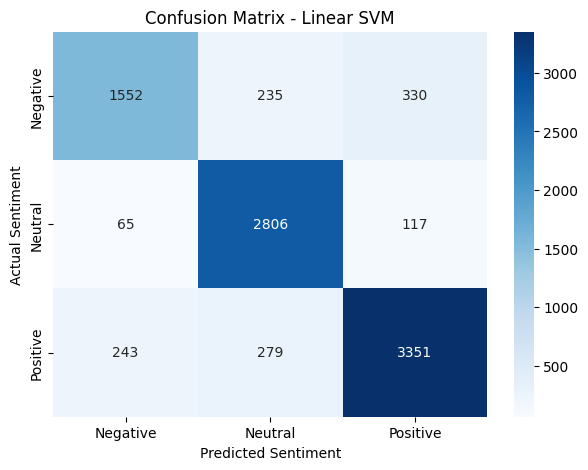

In [36]:
# Create confusion matrix for Linear SVM

cm = confusion_matrix(y_test, best_predictions)

labels = ["Negative", "Neutral", "Positive"]

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

### Confusion Matrix Explanation

The confusion matrix shows the performance of the Linear SVM model on the test dataset.

The model correctly predicted:
- 1,552 negative posts
- 2,806 neutral posts
- 3,351 positive posts

The model performed best on neutral and positive sentiment.  
Negative sentiment was more difficult because some negative posts were misclassified as neutral or positive.

Overall, the confusion matrix shows that most predictions are on the diagonal, which means the model is performing well.

## Classification Report

The classification report gives detailed evaluation metrics for each sentiment class: negative, neutral, and positive.

In [37]:
# Show classification report for Linear SVM

print("Classification Report - Linear SVM")
print(classification_report(
    y_test,
    best_predictions,
    target_names=["Negative", "Neutral", "Positive"]
))

Classification Report - Linear SVM
              precision    recall  f1-score   support

    Negative       0.83      0.73      0.78      2117
     Neutral       0.85      0.94      0.89      2988
    Positive       0.88      0.87      0.87      3873

    accuracy                           0.86      8978
   macro avg       0.85      0.85      0.85      8978
weighted avg       0.86      0.86      0.86      8978



### Classification Report Explanation

The Linear SVM model achieved an overall accuracy of 0.86, meaning it correctly classified about 86% of the test data.

For negative sentiment, the model achieved:
- Precision: 0.83
- Recall: 0.73
- F1-score: 0.78

This means the model can identify negative sentiment, but it misses some negative posts compared to the other classes.

For neutral sentiment, the model achieved:
- Precision: 0.85
- Recall: 0.94
- F1-score: 0.89

This is the strongest result. The high recall shows that the model correctly identifies most neutral posts.

For positive sentiment, the model achieved:
- Precision: 0.88
- Recall: 0.87
- F1-score: 0.87

This shows strong and balanced performance for positive sentiment.

Overall, the weighted average F1-score is 0.86, which shows that the Linear SVM model performed well across all sentiment classes.

## Final Evaluation Metrics

This table summarizes the final performance of the best model using accuracy, precision, recall, and F1-score.

In [38]:
# Calculate final evaluation metrics for Linear SVM

final_accuracy = accuracy_score(y_test, best_predictions)
final_precision = precision_score(y_test, best_predictions, average="weighted")
final_recall = recall_score(y_test, best_predictions, average="weighted")
final_f1 = f1_score(y_test, best_predictions, average="weighted")

# Create final metrics table
final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [final_accuracy, final_precision, final_recall, final_f1]
})

# Round scores for cleaner display
final_metrics["Score"] = final_metrics["Score"].round(6)

display(final_metrics)

,Metric,Score
0,Accuracy,0.858654
1,Precision,0.858656
2,Recall,0.858654
3,F1-Score,0.857025


### Final Metrics Explanation

The Linear SVM model achieved the following final results:

- Accuracy: 0.858654
- Precision: 0.858656
- Recall: 0.858654
- F1-score: 0.857025

These results show that the model correctly classified about 86% of the test data.

The F1-score is also close to 0.86, which means the model has a good balance between precision and recall.

Overall, the Linear SVM model shows strong performance for sentiment analysis of Twitter and Reddit discussions.

## Model Comparison

This chart compares the performance of the trained models using F1-score.

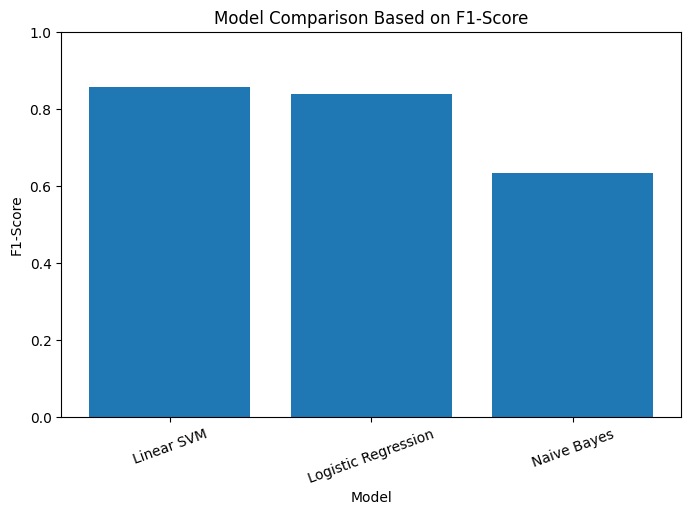

In [39]:
# Create model comparison chart using the results from Part 5

plt.figure(figsize=(8, 5))

plt.bar(results_df["Model"], results_df["F1-Score"])

plt.title("Model Comparison Based on F1-Score")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.show()

### Model Comparison Explanation

The model comparison chart shows that Linear SVM achieved the highest F1-score among the tested models.

Linear SVM performed slightly better than Logistic Regression and much better than Naive Bayes.

Because F1-score balances precision and recall, it is a strong metric for comparing classification models.

Based on this result, Linear SVM was selected as the best model for this project.

## Strengths of the Model

The Linear SVM model has several strengths for this sentiment analysis project.

First, it achieved strong overall performance with an accuracy of about 86% and an F1-score of about 86%.

Second, Linear SVM works well with TF-IDF features, which makes it suitable for text classification tasks.

Third, the model performed well on neutral and positive sentiment, which were the largest and strongest classes in the dataset.

Finally, the model is simple, fast, and easy to explain compared to more advanced deep learning models.

## Limitations of the Model

The model also has some limitations.

First, negative sentiment had lower recall than neutral and positive sentiment. This means the model missed some negative posts and classified them as another sentiment.

Second, TF-IDF does not understand deep context. It looks at word importance, but it does not fully understand sarcasm, slang, jokes, or emotional meaning.

Third, social media text can be noisy and informal. Posts may include misspellings, emojis, abbreviations, or mixed language, which can make sentiment classification harder.

Finally, the model depends on the quality of the dataset labels. If some labels are incorrect or unclear, the model may learn wrong patterns.

## Future Improvements

In the future, the model could be improved in several ways.

First, the dataset could be expanded and balanced so that each sentiment class has a similar number of examples.

Second, the text preprocessing could be improved by handling emojis, slang, abbreviations, and misspelled words more carefully.

Third, more advanced NLP models such as BERT or other transformer-based models could be tested to better understand context and meaning.

Finally, a simple web demo could be created where users enter a social media post and the system predicts whether it is negative, neutral, or positive.

## Final Evaluation Summary

The final model selected for this project was Linear SVM.

Linear SVM achieved the best performance among the tested models, with an accuracy of 0.858654 and a weighted F1-score of 0.857025.

The model performed especially well on neutral and positive sentiment. Negative sentiment was more challenging because some negative posts were misclassified as neutral or positive.

Overall, the project successfully demonstrates a complete NLP machine learning pipeline, including data preprocessing, exploratory data analysis, TF-IDF feature extraction, model training, model comparison, and final evaluation.

The results show that traditional machine learning models such as Linear SVM can perform well on sentiment analysis tasks when combined with proper text cleaning and TF-IDF feature extraction.

In [41]:
# Save final evaluation metrics as CSV

final_metrics.to_csv("final_evaluation_metrics.csv", index=False)

print("Final evaluation metrics saved successfully.")

Final evaluation metrics saved successfully.


In [42]:
# Save model comparison results as CSV

results_df.to_csv("model_comparison_results.csv", index=False)

print("Model comparison results saved successfully.")

Model comparison results saved successfully.
